### **Flowers Detection Project**

### **1.Load Library**

In [53]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset,DataLoader
import torch.nn.functional as F
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import splitfolders
from torchvision.utils import make_grid
from torchsummary import summary
from torchvision import models,datasets,transforms
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

### **Define Transform**

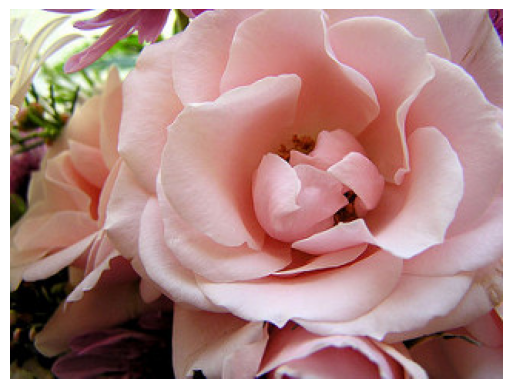

Width: 320
Height: 240


In [5]:
image = Image.open("rose.jpg")
plt.imshow(image)
plt.axis("off")
plt.show()
print("Width:", image.width)
print("Height:", image.height)

In [6]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

### **2.Prepare Train and Test Sets and DataLoader**

In [30]:
splitfolders.ratio("flowers",output = "Output_two",seed = 42,ratio = (0.8,0.2))

In [31]:
train = datasets.ImageFolder("Output_two/train",transform = transform)
test = datasets.ImageFolder("Output_two/val",transform = transform)

In [32]:
print(len(train))
print(len(test))

3452
865


In [33]:
train_loader = DataLoader(train,batch_size = 32,shuffle = True,drop_last = True)
test_loader = DataLoader(test,batch_size = 32,shuffle = False,drop_last = True)

### **3.Display Batch of Image**

In [9]:
for image,label in train_loader:
    break
print(image.shape)
print(image)
print("="*50)
print(label.shape)
print(label)

torch.Size([32, 3, 224, 224])
tensor([[[[-2.0323, -2.0152, -1.9980,  ..., -2.0152, -2.0152, -1.9980],
          [-2.0323, -2.0152, -1.9809,  ..., -2.0323, -2.0152, -1.9980],
          [-2.0323, -1.9980, -1.9638,  ..., -2.0323, -2.0323, -2.0152],
          ...,
          [-2.1008, -2.1008, -2.1008,  ..., -1.8439, -1.8268, -1.9124],
          [-2.1008, -2.1008, -2.1008,  ..., -1.7925, -1.7925, -1.9124],
          [-2.1008, -2.1008, -2.1008,  ..., -1.7412, -1.7754, -1.8953]],

         [[-1.9482, -1.9307, -1.9307,  ..., -1.8957, -1.8957, -1.8782],
          [-1.9482, -1.9307, -1.9132,  ..., -1.9132, -1.8957, -1.8782],
          [-1.9482, -1.9132, -1.8957,  ..., -1.9132, -1.9132, -1.8957],
          ...,
          [-2.0182, -2.0182, -2.0182,  ..., -1.8256, -1.8081, -1.8782],
          [-2.0182, -2.0182, -2.0182,  ..., -1.7906, -1.7731, -1.8431],
          [-2.0182, -2.0182, -2.0182,  ..., -1.7906, -1.7556, -1.8256]],

         [[-1.7522, -1.7347, -1.7347,  ..., -1.7522, -1.7522, -1.7347],


In [10]:
classes = train.classes
print(classes)

['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


Labels  [0 0 4 4 4 1 0 3 1 1 2 0 2 3 0 3 1 1 1 3 4 4 4 3 2 0 4 3 4 1 2 1]
Classes : daisy daisy tulip tulip tulip dandelion daisy sunflower dandelion dandelion rose daisy rose sunflower daisy sunflower dandelion dandelion dandelion sunflower tulip tulip tulip sunflower rose daisy tulip sunflower tulip dandelion rose dandelion


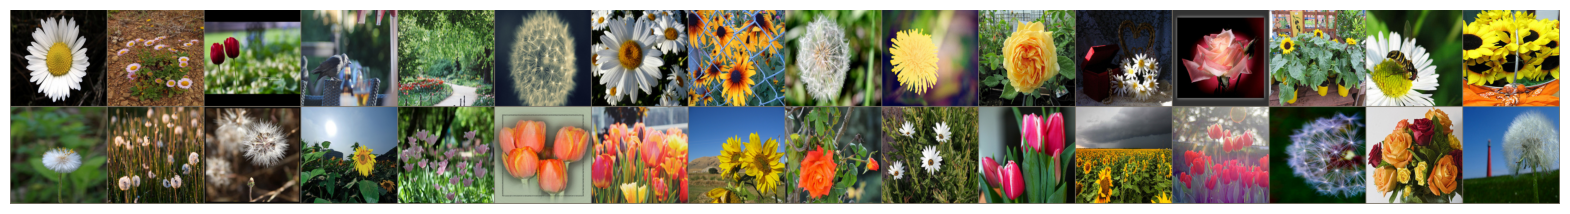

In [11]:
# print the labels

print("Labels ",label.numpy())
print("Classes :",*np.array([classes[i] for i in label]))

# Make a grid of images
im = make_grid(image, nrow=16)

# Inverse normalize the images
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

im_inv = inv_normalize(im)

# Show the image
plt.figure(figsize=(20,16))
plt.imshow(np.transpose(im_inv.numpy(), (1,2,0)))
plt.axis("off")
plt.show()

### **4.Import EfficientNet-B0**

In [12]:
weight = EfficientNet_B0_Weights.DEFAULT
model = efficientnet_b0(weights = weight)


In [13]:
model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          

### **5.Freeze all layer**

In [14]:
# freeze all layers

for param in model.parameters():
    param.requires_grad = False

### **6.Unfreeze the last layer**

In [15]:
model.classifier[1] = nn.Linear(model.classifier[1].in_features,5)

In [16]:
print(model.classifier[1])

Linear(in_features=1280, out_features=5, bias=True)


In [17]:
# count the number of parameter in the module

summary(model.cuda(),(3,116,116))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 58, 58]             864
       BatchNorm2d-2           [-1, 32, 58, 58]              64
              SiLU-3           [-1, 32, 58, 58]               0
            Conv2d-4           [-1, 32, 58, 58]             288
       BatchNorm2d-5           [-1, 32, 58, 58]              64
              SiLU-6           [-1, 32, 58, 58]               0
 AdaptiveAvgPool2d-7             [-1, 32, 1, 1]               0
            Conv2d-8              [-1, 8, 1, 1]             264
              SiLU-9              [-1, 8, 1, 1]               0
           Conv2d-10             [-1, 32, 1, 1]             288
          Sigmoid-11             [-1, 32, 1, 1]               0
SqueezeExcitation-12           [-1, 32, 58, 58]               0
           Conv2d-13           [-1, 16, 58, 58]             512
      BatchNorm2d-14           [-1, 16,

### **7.Early stopping Criteria**

In [27]:
import numpy as np


class EarlyStoppingCriterion:

    def __init__(self, patience=5, delta=0):

        self.patience = patience
        self.delta = delta

        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, val_loss):

        score = -val_loss

        # First epoch
        if self.best_score is None:

            self.best_score = score

        # No improvement
        elif score < self.best_score + self.delta:

            self.counter += 1

            print(
                f"EarlyStopping Counter: "
                f"{self.counter}/{self.patience}"
            )

            if self.counter >= self.patience:

                self.early_stop = True

        # Improvement
        else:

            self.best_score = score
            self.counter = 0

### **8.Training and Testing**

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [20]:
# ==========================
# Hyperparameters
# ==========================

learning_rate = 0.01
epochs = 500


# ==========================
# Loss Function & Optimizer
# ==========================

loss_func = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=learning_rate,
    momentum=0.9
)


# ==========================
# Store Results
# ==========================

train_losses = []
val_losses = []

train_accuracy = []
val_accuracy = []


# ==========================
# Early Stopping
# ==========================

early_stopping = EarlyStoppingCriterion()


# ==========================
# Training Loop
# ==========================

for epoch in range(epochs):

    # ==========================
    # TRAINING
    # ==========================

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (X_batch, y_batch) in enumerate(train_loader):

        X_batch = X_batch.to(device)
        y_batch = y_batch.long().to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = loss_func(outputs, y_batch)

        loss.backward()

        optimizer.step()

        # Loss
        running_loss += loss.item()

        # Accuracy
        _, predicted = torch.max(outputs, 1)

        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

        # Batch progress
        if batch_idx % 10 == 0:
            print(
                f"Epoch {epoch+1}/{epochs} | "
                f"Batch {batch_idx+1}/{len(train_loader)}"
            )

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = 100 * correct / total

    train_losses.append(epoch_train_loss)
    train_accuracy.append(epoch_train_acc)


    # ==========================
    # VALIDATION
    # ==========================

    model.eval()

    running_val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for X_batch, y_batch in test_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.long().to(device)

            outputs = model(X_batch)

            loss = loss_func(outputs, y_batch)

            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()

    epoch_val_loss = running_val_loss / len(test_loader)
    epoch_val_acc = 100 * correct / total

    val_losses.append(epoch_val_loss)
    val_accuracy.append(epoch_val_acc)


    # ==========================
    # EARLY STOPPING
    # ==========================

    early_stopping(epoch_val_loss)


    # ==========================
    # EPOCH RESULT
    # ==========================

    print(
        f"\nEpoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Train Acc: {epoch_train_acc:.2f}% | "
        f"Val Acc: {epoch_val_acc:.2f}%"
    )


    # ==========================
    # STOP TRAINING
    # ==========================

    if early_stopping.early_stop:

        print("\nEarly Stopping Triggered!")
        break

Epoch 1/500 | Batch 1/107
Epoch 1/500 | Batch 11/107
Epoch 1/500 | Batch 21/107
Epoch 1/500 | Batch 31/107
Epoch 1/500 | Batch 41/107
Epoch 1/500 | Batch 51/107
Epoch 1/500 | Batch 61/107
Epoch 1/500 | Batch 71/107
Epoch 1/500 | Batch 81/107
Epoch 1/500 | Batch 91/107
Epoch 1/500 | Batch 101/107

Epoch [1/500] | Train Loss: 0.6379 | Val Loss: 0.3686 | Train Acc: 78.18% | Val Acc: 86.92%
Epoch 2/500 | Batch 1/107
Epoch 2/500 | Batch 11/107
Epoch 2/500 | Batch 21/107
Epoch 2/500 | Batch 31/107
Epoch 2/500 | Batch 41/107
Epoch 2/500 | Batch 51/107
Epoch 2/500 | Batch 61/107
Epoch 2/500 | Batch 71/107
Epoch 2/500 | Batch 81/107
Epoch 2/500 | Batch 91/107
Epoch 2/500 | Batch 101/107

Epoch [2/500] | Train Loss: 0.3785 | Val Loss: 0.3327 | Train Acc: 87.82% | Val Acc: 89.00%
Epoch 3/500 | Batch 1/107
Epoch 3/500 | Batch 11/107
Epoch 3/500 | Batch 21/107
Epoch 3/500 | Batch 31/107
Epoch 3/500 | Batch 41/107
Epoch 3/500 | Batch 51/107
Epoch 3/500 | Batch 61/107
Epoch 3/500 | Batch 71/107
Epoch

In [21]:
torch.save(model.state_dict(), "efficientnet_b0_flowers.pth")

print("Model saved successfully!")

Model saved successfully!


### **Load the saved model**

In [1]:
import torch
import torch.nn as nn

from torchvision.models import (
    efficientnet_b0,
    EfficientNet_B0_Weights
)


# Device
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


# Create model
model = efficientnet_b0(
    weights=EfficientNet_B0_Weights.DEFAULT
)


# 5 flower classes
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    5
)


# Load trained weights
model.load_state_dict(
    torch.load(
        "efficientnet_b0_flowers.pth",
        weights_only=True
    )
)


# Move to GPU/CPU
model = model.to(device)


# Evaluation mode
model.eval()

print("Model loaded successfully!")

Model loaded successfully!


In [2]:
model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          

Prediction: rose
Confidence: 100.00%


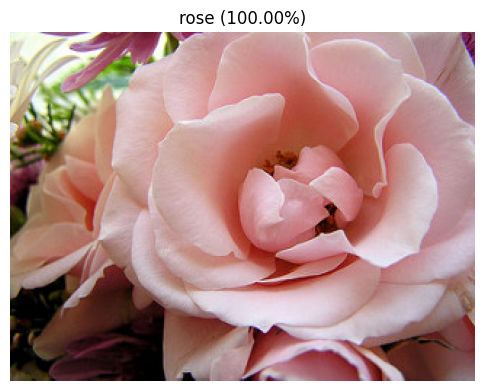

In [58]:
from PIL import Image
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Get class names directly from ImageFolder
class_names = [
    "daisy",
    "dandelion",
    "rose",
    "sunflower",
    "tulip"

]

# Confidence threshold
threshold = 0.70       # 70%

# Load image
image_path = "rose.jpg"
original_image = Image.open(image_path).convert("RGB")

# Transform image
image = transform(original_image)

# Add batch dimension
image = image.unsqueeze(0)

# Move to device
image = image.to(device)

# Prediction
model.eval()

with torch.no_grad():

    output = model(image)

    # Convert logits into probabilities
    probabilities = F.softmax(output, dim=1)

    # Get highest probability
    confidence, predicted_class = torch.max(probabilities, dim=1)

    confidence = confidence.item()
    predicted_class = predicted_class.item()

# Get flower name
flower_name = class_names[predicted_class]

# Check confidence
if confidence >= threshold:

    result = f"{flower_name} ({confidence * 100:.2f}%)"

    print("Prediction:", flower_name)
    print("Confidence:", f"{confidence * 100:.2f}%")

else:

    result = f"Not a supported flower ({confidence * 100:.2f}%)"

    print("❌ This image does not belong to the flower categories.")
    print("Confidence:", f"{confidence * 100:.2f}%")

# Show image
plt.figure(figsize=(6, 6))
plt.imshow(original_image)
plt.title(result)
plt.axis("off")
plt.show()

### **9.HyperTune the model**

**9.1.Freeze all Layers**

In [22]:
for param in model.parameters():
    param.requires_grad = False

**9.2 Unfreeze the Last two layer**

In [23]:
for param in model.features[-2:].parameters():
    param.requires_grad = True
    

**9.3 Unfreeze Classifier**

In [24]:
for param in model.classifier.parameters():
    param.requires_grad = True

In [25]:
for name,param in model.named_parameters():
    if (param.requires_grad):
        print(name)

features.7.0.block.0.0.weight
features.7.0.block.0.1.weight
features.7.0.block.0.1.bias
features.7.0.block.1.0.weight
features.7.0.block.1.1.weight
features.7.0.block.1.1.bias
features.7.0.block.2.fc1.weight
features.7.0.block.2.fc1.bias
features.7.0.block.2.fc2.weight
features.7.0.block.2.fc2.bias
features.7.0.block.3.0.weight
features.7.0.block.3.1.weight
features.7.0.block.3.1.bias
features.8.0.weight
features.8.1.weight
features.8.1.bias
classifier.1.weight
classifier.1.bias


### **10.Training and Testing the data**

In [34]:
# ==========================
# Hyperparameters
# ==========================

learning_rate = 0.0001
epochs = 50


# ==========================
# Loss Function & Optimizer
# ==========================

loss_func = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=learning_rate
)


# ==========================
# Store Results
# ==========================

train_losses = []
val_losses = []

train_accuracy = []
val_accuracy = []


# ==========================
# Early Stopping
# ==========================

early_stopping = EarlyStoppingCriterion()


# ==========================
# Training Loop
# ==========================

for epoch in range(epochs):

    # ==========================
    # TRAINING
    # ==========================

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (X_batch, y_batch) in enumerate(train_loader):

        X_batch = X_batch.to(device)
        y_batch = y_batch.long().to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = loss_func(outputs, y_batch)

        loss.backward()

        optimizer.step()

        # Loss
        running_loss += loss.item()

        # Accuracy
        _, predicted = torch.max(outputs, 1)

        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

        # Batch progress
        if batch_idx % 10 == 0:
            print(
                f"Epoch {epoch+1}/{epochs} | "
                f"Batch {batch_idx+1}/{len(train_loader)}"
            )

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = 100 * correct / total

    train_losses.append(epoch_train_loss)
    train_accuracy.append(epoch_train_acc)


    # ==========================
    # VALIDATION
    # ==========================

    model.eval()

    running_val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for X_batch, y_batch in test_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.long().to(device)

            outputs = model(X_batch)

            loss = loss_func(outputs, y_batch)

            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()

    epoch_val_loss = running_val_loss / len(test_loader)
    epoch_val_acc = 100 * correct / total

    val_losses.append(epoch_val_loss)
    val_accuracy.append(epoch_val_acc)


    # ==========================
    # EARLY STOPPING
    # ==========================

    early_stopping(epoch_val_loss)


    # ==========================
    # EPOCH RESULT
    # ==========================

    print(
        f"\nEpoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Train Acc: {epoch_train_acc:.2f}% | "
        f"Val Acc: {epoch_val_acc:.2f}%"
    )


    # ==========================
    # STOP TRAINING
    # ==========================

    if early_stopping.early_stop:

        print("\nEarly Stopping Triggered!")
        break

Epoch 1/50 | Batch 1/107
Epoch 1/50 | Batch 11/107
Epoch 1/50 | Batch 21/107
Epoch 1/50 | Batch 31/107
Epoch 1/50 | Batch 41/107
Epoch 1/50 | Batch 51/107
Epoch 1/50 | Batch 61/107
Epoch 1/50 | Batch 71/107
Epoch 1/50 | Batch 81/107
Epoch 1/50 | Batch 91/107
Epoch 1/50 | Batch 101/107

Epoch [1/50] | Train Loss: 0.2335 | Val Loss: 0.2708 | Train Acc: 91.73% | Val Acc: 90.51%
Epoch 2/50 | Batch 1/107
Epoch 2/50 | Batch 11/107
Epoch 2/50 | Batch 21/107
Epoch 2/50 | Batch 31/107
Epoch 2/50 | Batch 41/107
Epoch 2/50 | Batch 51/107
Epoch 2/50 | Batch 61/107
Epoch 2/50 | Batch 71/107
Epoch 2/50 | Batch 81/107
Epoch 2/50 | Batch 91/107
Epoch 2/50 | Batch 101/107

Epoch [2/50] | Train Loss: 0.1699 | Val Loss: 0.2512 | Train Acc: 94.22% | Val Acc: 91.32%
Epoch 3/50 | Batch 1/107
Epoch 3/50 | Batch 11/107
Epoch 3/50 | Batch 21/107
Epoch 3/50 | Batch 31/107
Epoch 3/50 | Batch 41/107
Epoch 3/50 | Batch 51/107
Epoch 3/50 | Batch 61/107
Epoch 3/50 | Batch 71/107
Epoch 3/50 | Batch 81/107
Epoch 3/50 

Prediction: dandelion
Confidence: 99.99%


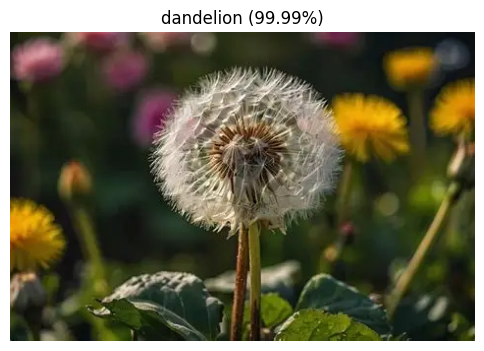

In [60]:
from PIL import Image
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Get class names directly from ImageFolder
class_names = [
    "daisy",
    "dandelion",
    "rose",
    "sunflower",
    "tulip"

]

# Confidence threshold
threshold = 0.70       # 70%

# Load image
image_path = "dand.webp"
original_image = Image.open(image_path).convert("RGB")

# Transform image
image = transform(original_image)

# Add batch dimension
image = image.unsqueeze(0)

# Move to device
image = image.to(device)

# Prediction
model.eval()

with torch.no_grad():

    output = model(image)

    # Convert logits into probabilities
    probabilities = F.softmax(output, dim=1)

    # Get highest probability
    confidence, predicted_class = torch.max(probabilities, dim=1)

    confidence = confidence.item()
    predicted_class = predicted_class.item()

# Get flower name
flower_name = class_names[predicted_class]

# Check confidence
if confidence >= threshold:

    result = f"{flower_name} ({confidence * 100:.2f}%)"

    print("Prediction:", flower_name)
    print("Confidence:", f"{confidence * 100:.2f}%")

else:

    result = f"Not a supported flower ({confidence * 100:.2f}%)"

    print("❌ This image does not belong to the flower categories.")
    print("Confidence:", f"{confidence * 100:.2f}%")

# Show image
plt.figure(figsize=(6, 6))
plt.imshow(original_image)
plt.title(result)
plt.axis("off")
plt.show()

In [44]:
torch.save(model.state_dict(), "efficientnet_b0_flowers_two.pth")

print("Model saved successfully!")

Model saved successfully!
